<a href="https://colab.research.google.com/github/reddytian/dl-learning/blob/main/day3_mnist_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 3 — MNIST Neural Network Classifier (PyTorch)

A simple fully-connected neural network trained to classify handwritten digits (MNIST, 0–9).

**What this notebook covers:**
- Loading image data with `DataLoader`
- Defining a neural network with a non-linear activation (ReLU)
- The core training loop (forward → loss → backward → optimizer step)
- Evaluation: accuracy, confusion matrix, classification report
- Checking for overfitting (train vs. test accuracy)

**Result:** ~97.5% test accuracy, with a healthy train/test gap (no significant overfitting).


## 1. Load the data (MNIST)


100%|██████████| 9.91M/9.91M [00:00<00:00, 62.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.60MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.33MB/s]


Train: 60000 images, Test: 10000 images
Batch shape: torch.Size([64, 1, 28, 28])


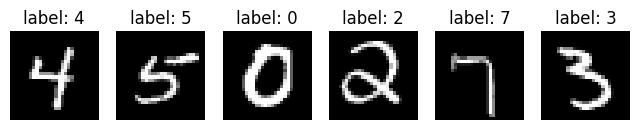

In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Convert images to tensors
transform = transforms.ToTensor()

# Download MNIST (28x28 grayscale handwritten digits)
train_data = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_data  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# DataLoaders feed the model mini-batches
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=1000)

print(f'Train: {len(train_data)} images, Test: {len(test_data)} images')

# Preview a few images
images, labels = next(iter(train_loader))
print('Batch shape:', images.shape)   # [64, 1, 28, 28]
plt.figure(figsize=(8, 2))
for i in range(6):
    plt.subplot(1, 6, i + 1)
    plt.imshow(images[i][0], cmap='gray')
    plt.title(f'label: {labels[i].item()}')
    plt.axis('off')
plt.show()

## 2. Define the neural network

The key ingredient is `nn.ReLU()` — a non-linearity. Without it, the network could only learn linear relationships; with it, it can learn the complex patterns needed to recognize digits.


In [2]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()          # 28x28 image -> 784-length vector
        self.fc1 = nn.Linear(28 * 28, 128)   # hidden layer
        self.relu = nn.ReLU()                # non-linear activation
        self.fc2 = nn.Linear(128, 10)        # output layer: one score per digit (0-9)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = Net().to(device)
print('Using device:', device)
print(model)

Using device: cpu
Net(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


## 3. Train the model

The training loop is the heart of deep learning. Each step:
1. **Forward pass** — the model makes predictions
2. **Loss** — measure how wrong the predictions are
3. **Zero gradients** — clear the previous step's gradients
4. **Backward pass** — autograd computes gradients
5. **Optimizer step** — update the weights to reduce the loss


Epoch 1 | train loss = 0.3394
Epoch 2 | train loss = 0.1499
Epoch 3 | train loss = 0.1050
Epoch 4 | train loss = 0.0810
Epoch 5 | train loss = 0.0634


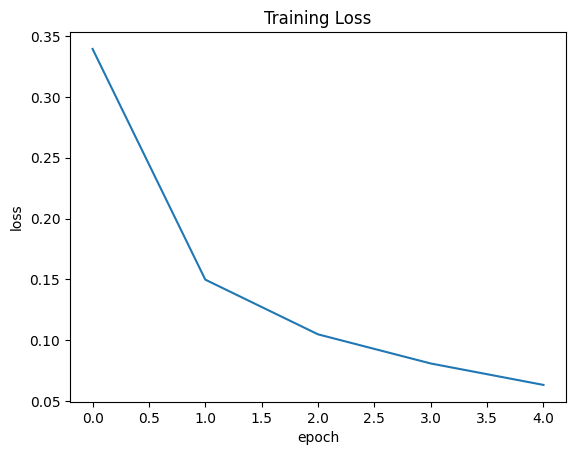

In [3]:
loss_fn = nn.CrossEntropyLoss()                              # classification loss
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)  # optimizer

train_losses = []
for epoch in range(5):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        y_pred = model(images)            # 1. forward pass
        loss = loss_fn(y_pred, labels)    # 2. loss
        optimizer.zero_grad()             # 3. zero gradients
        loss.backward()                   # 4. backward pass
        optimizer.step()                  # 5. update weights

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f'Epoch {epoch + 1} | train loss = {avg_loss:.4f}')

plt.plot(train_losses)
plt.xlabel('epoch'); plt.ylabel('loss'); plt.title('Training Loss')
plt.show()

## 4. Evaluate the model

Measure accuracy on the held-out test set, and inspect the confusion matrix and per-class metrics (precision / recall / F1).


Test accuracy: 97.36%



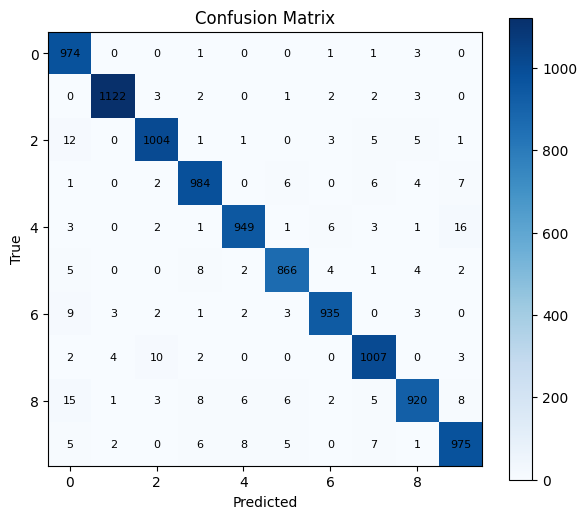

              precision    recall  f1-score   support

           0       0.95      0.99      0.97       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.97      0.97      0.97      1010
           4       0.98      0.97      0.97       982
           5       0.98      0.97      0.97       892
           6       0.98      0.98      0.98       958
           7       0.97      0.98      0.98      1028
           8       0.97      0.94      0.96       974
           9       0.96      0.97      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [4]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():                       # no gradients needed for evaluation
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu()  # pick the highest-scoring digit
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

acc = accuracy_score(all_labels, all_preds)
print(f'Test accuracy: {acc * 100:.2f}%\n')

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 6))
plt.imshow(cm, cmap='Blues')
plt.colorbar(); plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix')
for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=8)
plt.show()

print(classification_report(all_labels, all_preds))

## 5. Check for overfitting

A model can score high on the test set but still be **overfitting** if it does far better on the training data than on unseen data. The check is simple: compare **train vs. test accuracy** — a small gap means the model generalizes well.

| Situation | Train acc | Test acc | Meaning |
|---|---|---|---|
| Healthy | high | high | learned to generalize |
| Overfitting | very high | lower | memorized the training data |
| Underfitting | low | low | model too simple / undertrained |


In [5]:
def evaluate(loader, name):
    model.eval()
    preds, labels_all = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            preds.extend(model(images).argmax(1).cpu().numpy())
            labels_all.extend(labels.numpy())
    acc = accuracy_score(labels_all, preds)
    print(f'{name} accuracy: {acc * 100:.2f}%')
    return acc

train_acc = evaluate(train_loader, 'Train')
test_acc  = evaluate(test_loader,  'Test')
print(f'\nGap (train - test): {(train_acc - test_acc) * 100:.2f}%')

Train accuracy: 98.52%
Test accuracy: 97.36%

Gap (train - test): 1.16%


## Summary

- Trained a fully-connected neural network on MNIST and reached **~97.5% test accuracy**.
- The **train/test gap is small (~1%)**, so the model generalizes well — no significant overfitting.
- Core concepts practiced: the training loop, non-linearity (ReLU), loss/optimizer, evaluation metrics, and the overfitting check.

**Next:** convolutional neural networks (CNNs), which exploit the 2-D structure of images and typically outperform fully-connected networks on image tasks.
